In [1]:
# Install required libraries
!pip install lightgbm catboost scikit-learn pandas numpy -q



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import catboost as cb

import os


In [3]:
# ── Configuration ──────────────────────────────────────────
DATA_DIR = '/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment'

SEED = 42
N_FOLDS = 5          # GroupKFold by pid (LOSO-style)
WINDOW_SEC = 1       # 1-second base window for feature extraction
CONTEXT_SEC = 2      # ±2 second context window for richer features

LGBM_PARAMS = {
    'objective': 'multiclass',
    'num_class': 9,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'n_jobs': -1,
    'seed': SEED,
}

CAT_PARAMS = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1:average=Macro',
    'early_stopping_rounds': 150,
    'random_seed': SEED,
    'verbose': 0,
}

print("Config loaded.")


Config loaded.


In [4]:
# ── Load Raw Data ───────────────────────────────────────────
print("Loading sensor files (this may take ~1-2 minutes)...")

train_accel = pd.read_csv(os.path.join(DATA_DIR, 'train-accel.csv'))
train_gyro  = pd.read_csv(os.path.join(DATA_DIR, 'train-gyro.csv'))
train_label = pd.read_csv(os.path.join(DATA_DIR, 'train-label.csv'))

test_accel  = pd.read_csv(os.path.join(DATA_DIR, 'test-accel.csv'))
test_gyro   = pd.read_csv(os.path.join(DATA_DIR, 'test-gyro.csv'))
test_label  = pd.read_csv(os.path.join(DATA_DIR, 'test-label.csv'))

print(f"train_accel : {train_accel.shape}")
print(f"train_gyro  : {train_gyro.shape}")
print(f"train_label : {train_label.shape}")
print(f"test_accel  : {test_accel.shape}")
print(f"test_gyro   : {test_gyro.shape}")
print(f"test_label  : {test_label.shape}")


Loading sensor files (this may take ~1-2 minutes)...
train_accel : (2428374, 7)
train_gyro  : (2433673, 7)
train_label : (38015, 4)
test_accel  : (2528310, 7)
test_gyro   : (2541831, 7)
test_label  : (39473, 4)


In [5]:
# ── Feature Extraction ──────────────────────────────────────
def extract_window_features(arr, prefix):
    """
    Given a 1D numpy array of sensor readings in a window,
    extract a rich set of statistical and signal features.
    """
    feats = {}
    n = len(arr)
    if n == 0:
        # Return zeros if no data
        for k in ['mean','std','var','min','max','range','median',
                  'p25','p75','iqr','skew','kurt','rms','energy',
                  'zero_cross','mean_abs_diff','max_abs']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    feats[f'{prefix}_mean']          = np.mean(arr)
    feats[f'{prefix}_std']           = np.std(arr)
    feats[f'{prefix}_var']           = np.var(arr)
    feats[f'{prefix}_min']           = np.min(arr)
    feats[f'{prefix}_max']           = np.max(arr)
    feats[f'{prefix}_range']         = np.max(arr) - np.min(arr)
    feats[f'{prefix}_median']        = np.median(arr)
    feats[f'{prefix}_p25']           = np.percentile(arr, 25)
    feats[f'{prefix}_p75']           = np.percentile(arr, 75)
    feats[f'{prefix}_iqr']           = np.percentile(arr, 75) - np.percentile(arr, 25)
    feats[f'{prefix}_skew']          = stats.skew(arr) if n > 2 else 0.0
    feats[f'{prefix}_kurt']          = stats.kurtosis(arr) if n > 2 else 0.0
    feats[f'{prefix}_rms']           = np.sqrt(np.mean(arr**2))
    feats[f'{prefix}_energy']        = np.sum(arr**2) / n
    # Zero crossing rate
    feats[f'{prefix}_zero_cross']    = np.sum(np.diff(np.sign(arr - np.mean(arr))) != 0) / max(n-1, 1)
    feats[f'{prefix}_mean_abs_diff'] = np.mean(np.abs(np.diff(arr))) if n > 1 else 0.0
    feats[f'{prefix}_max_abs']       = np.max(np.abs(arr))
    return feats


def compute_features_for_split(accel_df, gyro_df, label_df, context=CONTEXT_SEC):
    """
    For each (pid, time_s) in label_df, aggregate sensor readings from
    [time_s - context, time_s + context] seconds into features.
    
    Returns a feature DataFrame aligned with label_df.
    """
    # Floor sensor times to integer seconds
    accel_df = accel_df.copy()
    gyro_df  = gyro_df.copy()
    label_df = label_df.copy()

    accel_df['time_s'] = accel_df['time'].astype(int)
    gyro_df['time_s']  = gyro_df['time'].astype(int)
    label_df['time_s'] = label_df['time'].astype(int)

    # Add derived columns to sensor data
    for df, name in [(accel_df, 'accel'), (gyro_df, 'gyro')]:
        df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

    # Build lookup: (pid, time_s) → sensor readings
    # Group sensor data by (pid, time_s)
    accel_grouped = accel_df.groupby(['pid', 'time_s'])
    gyro_grouped  = gyro_df.groupby(['pid', 'time_s'])

    # Build dict for fast lookup
    print("  Building accel lookup...")
    accel_lookup = {}
    for (pid, ts), grp in accel_grouped:
        accel_lookup[(pid, ts)] = grp[['x','y','z','mag']].values

    print("  Building gyro lookup...")
    gyro_lookup = {}
    for (pid, ts), grp in gyro_grouped:
        gyro_lookup[(pid, ts)] = grp[['x','y','z','mag']].values

    # Also get direction & device per (pid, time_s) from accel
    meta_lookup = {}
    for (pid, ts), grp in accel_grouped:
        meta_lookup[(pid, ts)] = {
            'direction': grp['direction'].iloc[0],
            'device':    1 if grp['device'].iloc[0] == 'Apple' else 0,
        }

    print("  Extracting features per label row...")
    all_feats = []

    for _, row in label_df.iterrows():
        pid = row['pid']
        ts  = int(row['time_s'])
        feat = {}

        # Collect sensor readings over context window
        a_x, a_y, a_z, a_mag = [], [], [], []
        g_x, g_y, g_z, g_mag = [], [], [], []

        for offset in range(-context, context + 1):
            key = (pid, ts + offset)
            if key in accel_lookup:
                chunk = accel_lookup[key]
                a_x.extend(chunk[:, 0])
                a_y.extend(chunk[:, 1])
                a_z.extend(chunk[:, 2])
                a_mag.extend(chunk[:, 3])
            if key in gyro_lookup:
                chunk = gyro_lookup[key]
                g_x.extend(chunk[:, 0])
                g_y.extend(chunk[:, 1])
                g_z.extend(chunk[:, 2])
                g_mag.extend(chunk[:, 3])

        # Convert to arrays
        a_x, a_y, a_z, a_mag = map(np.array, [a_x, a_y, a_z, a_mag])
        g_x, g_y, g_z, g_mag = map(np.array, [g_x, g_y, g_z, g_mag])

        # Per-axis features: accel
        feat.update(extract_window_features(a_x,   'ax'))
        feat.update(extract_window_features(a_y,   'ay'))
        feat.update(extract_window_features(a_z,   'az'))
        feat.update(extract_window_features(a_mag, 'amag'))

        # Per-axis features: gyro
        feat.update(extract_window_features(g_x,   'gx'))
        feat.update(extract_window_features(g_y,   'gy'))
        feat.update(extract_window_features(g_z,   'gz'))
        feat.update(extract_window_features(g_mag, 'gmag'))

        # Cross-sensor features
        if len(a_mag) > 0 and len(g_mag) > 0:
            min_len = min(len(a_mag), len(g_mag))
            feat['accel_gyro_mag_corr'] = (
                np.corrcoef(a_mag[:min_len], g_mag[:min_len])[0, 1]
                if min_len > 2 else 0.0
            )
        else:
            feat['accel_gyro_mag_corr'] = 0.0

        # Gravity component estimate (low-freq = mean of accel)
        feat['gravity_x'] = np.mean(a_x) if len(a_x) > 0 else 0.0
        feat['gravity_y'] = np.mean(a_y) if len(a_y) > 0 else 0.0
        feat['gravity_z'] = np.mean(a_z) if len(a_z) > 0 else 0.0
        feat['gravity_mag'] = np.sqrt(feat['gravity_x']**2 + feat['gravity_y']**2 + feat['gravity_z']**2)

        # Tilt angle estimate (angle of gravity vector)
        feat['tilt_xz'] = np.arctan2(feat['gravity_x'], feat['gravity_z']) if feat['gravity_mag'] > 0 else 0.0
        feat['tilt_yz'] = np.arctan2(feat['gravity_y'], feat['gravity_z']) if feat['gravity_mag'] > 0 else 0.0

        # n_samples (data quality indicator)
        feat['n_accel_samples'] = len(a_x)
        feat['n_gyro_samples']  = len(g_x)

        # Metadata
        if (pid, ts) in meta_lookup:
            feat['direction'] = meta_lookup[(pid, ts)]['direction']
            feat['device']    = meta_lookup[(pid, ts)]['device']
        else:
            feat['direction'] = -1
            feat['device']    = -1

        all_feats.append(feat)

    feat_df = pd.DataFrame(all_feats)
    # Align index
    feat_df.index = label_df.index
    return feat_df

print("Feature extraction functions defined.")


Feature extraction functions defined.


In [6]:
# ── Run Feature Extraction ──────────────────────────────────
print("Extracting TRAIN features...")
train_feats = compute_features_for_split(train_accel, train_gyro, train_label, context=CONTEXT_SEC)
print(f"Train features shape: {train_feats.shape}")

print("\nExtracting TEST features...")
test_feats = compute_features_for_split(test_accel, test_gyro, test_label, context=CONTEXT_SEC)
print(f"Test features shape: {test_feats.shape}")


Extracting TRAIN features...
  Building accel lookup...
  Building gyro lookup...
  Extracting features per label row...
Train features shape: (38015, 147)

Extracting TEST features...
  Building accel lookup...
  Building gyro lookup...
  Extracting features per label row...
Test features shape: (39473, 147)


In [7]:
# ── Prepare ML Inputs ───────────────────────────────────────
# Fill NaN (from missing sensor windows) with 0
train_feats = train_feats.fillna(0)
test_feats  = test_feats.fillna(0)

# Align columns
feat_cols = [c for c in train_feats.columns]
test_feats = test_feats[feat_cols]

X_train = train_feats.values
y_train = train_label['workout'].values
groups  = train_label['pid'].values   # for GroupKFold

X_test  = test_feats.values

# Identify PID-71 rows (no sensor data → predict separately)
pid71_mask = test_label['pid'] == '71'
has_sensor_mask = ~pid71_mask

print(f"Feature columns  : {len(feat_cols)}")
print(f"X_train shape    : {X_train.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"y_train classes  : {np.unique(y_train)}")
print(f"PID-71 rows      : {pid71_mask.sum()}")
print(f"Rows with sensor : {has_sensor_mask.sum()}")
print(f"\nClass distribution in train:")
for c, cnt in sorted(zip(*np.unique(y_train, return_counts=True))):
    print(f"  Class {c}: {cnt} ({cnt/len(y_train)*100:.1f}%)")


Feature columns  : 147
X_train shape    : (38015, 147)
X_test shape     : (39473, 147)
y_train classes  : [0 1 2 3 4 5 6 7 8]
PID-71 rows      : 1124
Rows with sensor : 38349

Class distribution in train:
  Class 0: 3389 (8.9%)
  Class 1: 3523 (9.3%)
  Class 2: 3575 (9.4%)
  Class 3: 3697 (9.7%)
  Class 4: 3610 (9.5%)
  Class 5: 3627 (9.5%)
  Class 6: 3589 (9.4%)
  Class 7: 3795 (10.0%)
  Class 8: 9210 (24.2%)


In [8]:
# ── LightGBM Training with GroupKFold ────────────────────────
gkf = GroupKFold(n_splits=N_FOLDS)

oof_lgbm  = np.zeros((len(X_train), 9))
pred_lgbm = np.zeros((len(X_test),  9))

lgbm_models = []
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feat_cols)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=feat_cols, reference=dtrain)

    model = lgb.train(
        LGBM_PARAMS,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    oof_lgbm[val_idx]  = model.predict(X_val, num_iteration=model.best_iteration)
    pred_lgbm          += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS

    oof_preds = np.argmax(oof_lgbm[val_idx], axis=1)
    score = balanced_accuracy_score(y_val, oof_preds)
    fold_scores.append(score)
    val_pids = np.unique(groups[val_idx])
    print(f"Fold {fold+1} | PIDs: {list(val_pids)} | BA: {score:.5f} | best_iter: {model.best_iteration}")
    lgbm_models.append(model)

overall_lgbm = balanced_accuracy_score(y_train, np.argmax(oof_lgbm, axis=1))
print(f"\nLGBM OOF Balanced Accuracy: {overall_lgbm:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.85199 | best_iter: 44
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.93545 | best_iter: 110
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.83563 | best_iter: 47
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.93845 | best_iter: 74
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.84376 | best_iter: 54

LGBM OOF Balanced Accuracy: 0.88017


In [9]:
# ── CatBoost Training with GroupKFold ────────────────────────
oof_cat  = np.zeros((len(X_train), 9))
pred_cat = np.zeros((len(X_test),  9))

cat_models = []
cat_fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = cb.CatBoostClassifier(**CAT_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        verbose=False,
    )

    oof_cat[val_idx]  = model.predict_proba(X_val)
    pred_cat          += model.predict_proba(X_test) / N_FOLDS

    oof_preds = np.argmax(oof_cat[val_idx], axis=1)
    score = balanced_accuracy_score(y_val, oof_preds)
    cat_fold_scores.append(score)
    val_pids = np.unique(groups[val_idx])
    print(f"Fold {fold+1} | PIDs: {list(val_pids)} | BA: {score:.5f} | best_iter: {model.best_iteration_}")
    cat_models.append(model)

overall_cat = balanced_accuracy_score(y_train, np.argmax(oof_cat, axis=1))
print(f"\nCatBoost OOF Balanced Accuracy: {overall_cat:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.86737 | best_iter: 1080
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.93468 | best_iter: 1722
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.84482 | best_iter: 1243
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.93601 | best_iter: 612
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.84755 | best_iter: 208

CatBoost OOF Balanced Accuracy: 0.88514


In [10]:
# ── Ensemble: Find Best Blend Weight ────────────────────────
best_score = 0
best_w = 0.5

for w in np.arange(0.0, 1.01, 0.05):
    blend_oof = w * oof_lgbm + (1 - w) * oof_cat
    score = balanced_accuracy_score(y_train, np.argmax(blend_oof, axis=1))
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best LGBM weight : {best_w:.2f}")
print(f"Best blend OOF BA: {best_score:.5f}")

# Final blended test predictions
pred_blend = best_w * pred_lgbm + (1 - best_w) * pred_cat
test_preds = np.argmax(pred_blend, axis=1)


Best LGBM weight : 0.35
Best blend OOF BA: 0.88690


In [11]:
# ── Handle PID '71' (no sensor data) ────────────────────────
# PID 71 has no sensor data at all.
# Strategy: predict the most common non-rest class per time position,
# or simply use the training class distribution (mode per second within segment).
# Safest default: use training class distribution weighted by Balanced Accuracy.

# Class frequencies in train (excluding rest for variety, but rest is valid)
class_counts = pd.Series(y_train).value_counts().sort_index()
class_probs  = (class_counts / class_counts.sum()).values
print("Class probabilities (train):", {i: f"{p:.3f}" for i, p in enumerate(class_probs)})

# For PID 71, we have no sensor signal → predict rest (8) 
# since the person may simply not have recorded data.
# Alternatively, distribute predictions proportionally.
# We'll use the safest single-class prediction: rest (8) — most common class.

pid71_prediction = 8   # rest
print(f"PID '71' rows ({pid71_mask.sum()}): assigned class {pid71_prediction} (rest)")


Class probabilities (train): {0: '0.089', 1: '0.093', 2: '0.094', 3: '0.097', 4: '0.095', 5: '0.095', 6: '0.094', 7: '0.100', 8: '0.242'}
PID '71' rows (1124): assigned class 8 (rest)


In [12]:
# ── Build Submission ────────────────────────────────────────
submission = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))

# Fill predictions for rows WITH sensor data
submission.loc[has_sensor_mask.values, 'workout'] = test_preds[has_sensor_mask.values]

# Fill PID 71
submission.loc[pid71_mask.values, 'workout'] = pid71_prediction

submission['workout'] = submission['workout'].astype(int)

print("Submission preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")
print(f"Unique predicted classes: {sorted(submission['workout'].unique())}")
print(f"\nPrediction distribution:")
print(submission['workout'].value_counts().sort_index())


Submission preview:
      id  workout
0  56209        8
1  56210        8
2  56211        8
3  56212        7
4  56213        7
5  56214        7
6  56215        7
7  56216        7
8  56217        7
9  56218        7

Submission shape: (39473, 2)
Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Prediction distribution:
workout
0    3775
1    3228
2    3670
3    3534
4    3784
5    3822
6    4227
7    3585
8    9848
Name: count, dtype: int64


In [13]:
# ── Save Submission ─────────────────────────────────────────
out_path = os.path.join(".", 'submission_v1.csv')
submission.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")
print("\nDone! ✓")


Saved to: ./submission_v1.csv

Done! ✓


Top 30 features:
            feature    importance
           amag_iqr 140186.403134
             ax_rms 101342.889234
         ax_max_abs  68705.839022
             gx_iqr  57455.237224
accel_gyro_mag_corr  51926.619045
             az_rms  51413.008619
             gy_rms  39693.248849
           amag_std  39242.295344
          ax_energy  29923.950077
             ax_std  22893.431743
           amag_min  20395.522700
           amag_p25  18569.724099
           amag_p75  14651.928694
      gy_zero_cross  14438.047499
             gz_std  13861.898412
             gx_std  12903.048943
        gravity_mag  12868.774284
             gx_rms  12141.428992
    amag_zero_cross  11281.974774
           ax_range   9783.551610
      gx_zero_cross   9066.413935
   gx_mean_abs_diff   8825.837802
    gmag_zero_cross   8626.105361
          az_energy   8239.728924
          gy_energy   8212.638453
           amag_var   8114.964195
          amag_skew   7687.626994
             gz_iqr   7590.1242

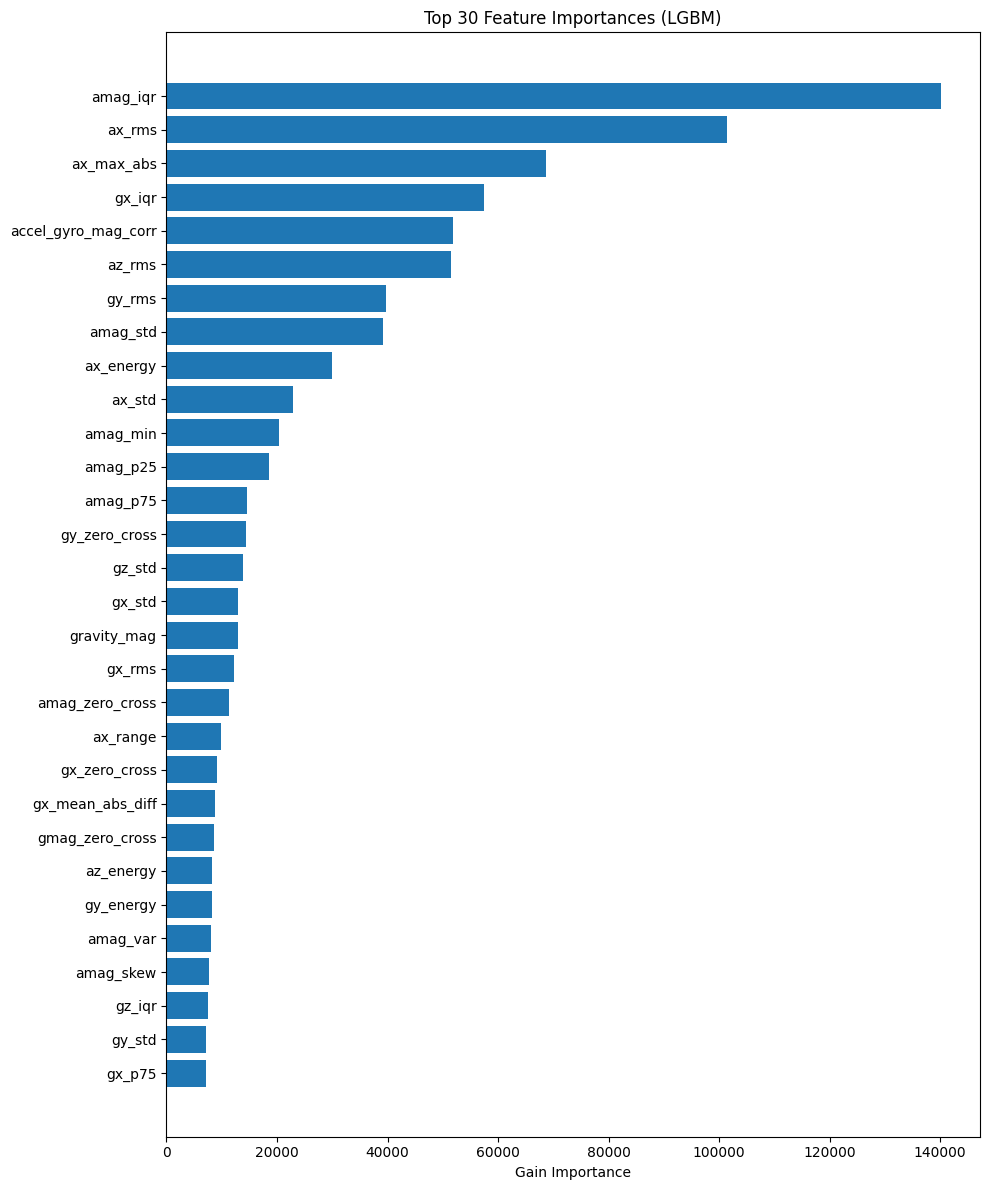

In [14]:
# ── Feature Importance (LGBM) ────────────────────────────────
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    'feature': feat_cols,
    'importance': lgbm_models[-1].feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

print("Top 30 features:")
print(fi.head(30).to_string(index=False))

plt.figure(figsize=(10, 12))
plt.barh(fi['feature'].head(30)[::-1], fi['importance'].head(30)[::-1])
plt.xlabel('Gain Importance')
plt.title('Top 30 Feature Importances (LGBM)')
plt.tight_layout()
plt.show()


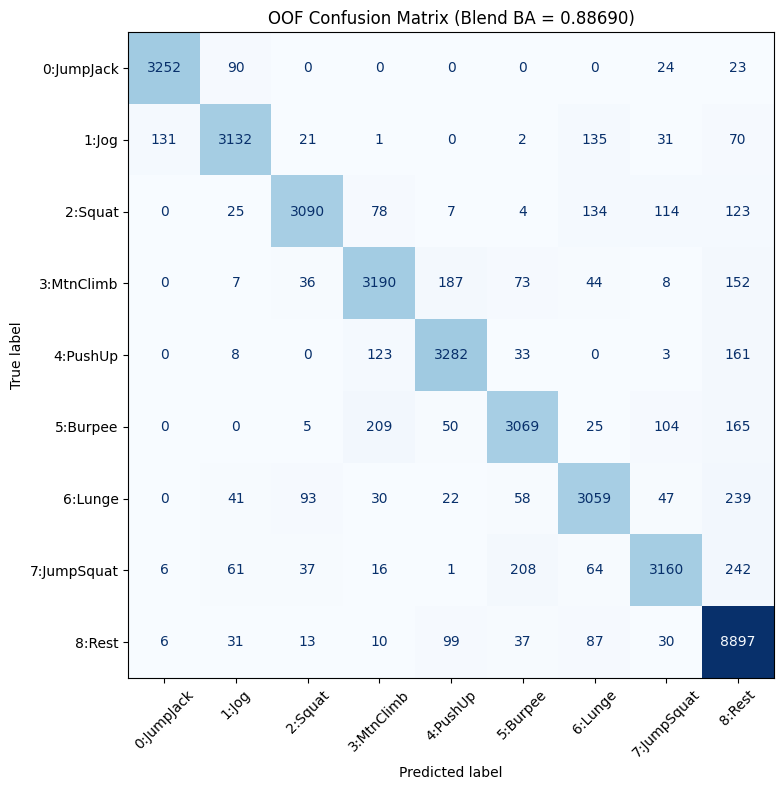


Per-class recall (sensitivity):
  0:JumpJack: 0.960
  1:Jog: 0.889
  2:Squat: 0.864
  3:MtnClimb: 0.863
  4:PushUp: 0.909
  5:Burpee: 0.846
  6:Lunge: 0.852
  7:JumpSquat: 0.833
  8:Rest: 0.966


In [15]:
# ── OOF Confusion Matrix ────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

blend_oof = best_w * oof_lgbm + (1 - best_w) * oof_cat
oof_pred_labels = np.argmax(blend_oof, axis=1)

class_names = [
    '0:JumpJack', '1:Jog', '2:Squat', '3:MtnClimb',
    '4:PushUp', '5:Burpee', '6:Lunge', '7:JumpSquat', '8:Rest'
]

cm = confusion_matrix(y_train, oof_pred_labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title(f'OOF Confusion Matrix (Blend BA = {best_score:.5f})')
plt.tight_layout()
plt.show()

# Per-class recall
print("\nPer-class recall (sensitivity):")
for i, name in enumerate(class_names):
    recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"  {name}: {recall:.3f}")
